In [25]:
# importações iniciais das bibliotecas a serem utilizadas
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from warnings import filterwarnings

# configurações a serem mantidas para a análise
filterwarnings("ignore")
pd.set_option("display.max_columns", None)
# pd.reset_option("display.max_columns")

# origem do dataframe
dataframe = pd.read_csv("/kaggle/input/datasets/yashdevladdha/uber-ride-analytics-dashboard/ncr_ride_bookings.csv")

In [26]:
# visualização inicial do dataframe
dataframe.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,NaN,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,NaN,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,NaN,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,NaN,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI


In [27]:
# verificação de tipos de dados e nans
dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  object 
 1   Time                               150000 non-null  object 
 2   Booking ID                         150000 non-null  object 
 3   Booking Status                     150000 non-null  object 
 4   Customer ID                        150000 non-null  object 
 5   Vehicle Type                       150000 non-null  object 
 6   Pickup Location                    150000 non-null  object 
 7   Drop Location                      150000 non-null  object 
 8   Avg VTAT                           139500 non-null  float64
 9   Avg CTAT                           102000 non-null  float64
 10  Cancelled Rides by Customer        10500 non-null   float64
 11  Reason for cancelling by Customer  1050

In [28]:
# verificação do tamanho do dataframe
dataframe.shape

(150000, 21)

In [29]:
# processo de renomeação de colunas (o autor visualiza melhor dessa forma)

display(dataframe.columns)

Index(['Date', 'Time', 'Booking ID', 'Booking Status', 'Customer ID',
       'Vehicle Type', 'Pickup Location', 'Drop Location', 'Avg VTAT',
       'Avg CTAT', 'Cancelled Rides by Customer',
       'Reason for cancelling by Customer', 'Cancelled Rides by Driver',
       'Driver Cancellation Reason', 'Incomplete Rides',
       'Incomplete Rides Reason', 'Booking Value', 'Ride Distance',
       'Driver Ratings', 'Customer Rating', 'Payment Method'],
      dtype='object')

In [30]:
dataframe = dataframe.rename(columns={
    "Date": "dt_carona",
    "Time": "hr_carona",
    "Booking ID": "id_carona",
    "Booking Status": "st_carona",
    "Customer ID": "id_cliente",
    "Vehicle Type": "tp_veiculo",
    "Pickup Location": "endereco_retirada",
    "Drop Location": "endereco_entrega",
    "Avg VTAT": "minutos_chegar_local",
    "Avg CTAT": "minutos_trazer_cliente",
    "Cancelled Rides by Customer": "cliente_cancelou",
    "Reason for cancelling by Customer": "motivo_cancelamento_cliente",
    "Cancelled Rides by Driver": "motorista_cancelou",
    "Driver Cancellation Reason": "motivo_cancelamento_motorista",
    "Incomplete Rides": "carona_incompleta",
    "Incomplete Rides Reason": "motivo_incompleta",
    "Booking Value": "vl_carona",
    "Ride Distance": "distancia_carona",
    "Driver Ratings": "avaliacao_motorista",
    "Customer Rating": "avaliacao_cliente",
    "Payment Method": "metodo_pagamento"
})


display(dataframe.columns)

Index(['dt_carona', 'hr_carona', 'id_carona', 'st_carona', 'id_cliente',
       'tp_veiculo', 'endereco_retirada', 'endereco_entrega',
       'minutos_chegar_local', 'minutos_trazer_cliente', 'cliente_cancelou',
       'motivo_cancelamento_cliente', 'motorista_cancelou',
       'motivo_cancelamento_motorista', 'carona_incompleta',
       'motivo_incompleta', 'vl_carona', 'distancia_carona',
       'avaliacao_motorista', 'avaliacao_cliente', 'metodo_pagamento'],
      dtype='object')

In [31]:
# alteração dos tipos de dados do dia e hora
dataframe["data_hora_carona"] = pd.to_datetime(dataframe["dt_carona"] + " " + dataframe["hr_carona"])

print(dataframe[["dt_carona", "hr_carona", "data_hora_carona"]].head())

    dt_carona hr_carona    data_hora_carona
0  2024-03-23  12:29:38 2024-03-23 12:29:38
1  2024-11-29  18:01:39 2024-11-29 18:01:39
2  2024-08-23  08:56:10 2024-08-23 08:56:10
3  2024-10-21  17:17:25 2024-10-21 17:17:25
4  2024-09-16  22:08:00 2024-09-16 22:08:00


In [32]:
# visualização de percentual de nans

nan_porcentual = dataframe.isnull().sum() / len(dataframe) * 100

nan_table = pd.DataFrame({"nans_totais": dataframe.isnull().sum(), "nans_porcentual": nan_porcentual, "not_nan_percentual": 100 - nan_porcentual})
nan_table = nan_table[nan_table["nans_totais"] > 0].sort_values(by="nans_porcentual", ascending=False)
# o que nao apareceu todos são sem nans

display(nan_table)

,nans_totais,nans_porcentual,not_nan_percentual
carona_incompleta,141000,94.0,6.0
motivo_incompleta,141000,94.0,6.0
cliente_cancelou,139500,93.0,7.0
motivo_cancelamento_cliente,139500,93.0,7.0
motorista_cancelou,123000,82.0,18.0
motivo_cancelamento_motorista,123000,82.0,18.0
avaliacao_motorista,57000,38.0,62.0
avaliacao_cliente,57000,38.0,62.0
minutos_trazer_cliente,48000,32.0,68.0
distancia_carona,48000,32.0,68.0


In [33]:
# visualização dos registros de cada coluna categórica e quantidade de nans
colunas_categoricas = [
    "st_carona",
    "tp_veiculo",
    "endereco_retirada",
    "metodo_pagamento"
]

for coluna in colunas_categoricas:
    print(f"Coluna: {coluna}")
    
    perc_nan = dataframe[coluna].isna().mean()
    if perc_nan > 0.20:
        print(f"A coluna possui muitos valores ausentes: {perc_nan:.2%}")
    contagem = dataframe[coluna].value_counts(dropna=False).head(10)
    
    if dataframe[coluna].nunique() > 10:
        print(f"A coluna tem {dataframe[coluna].nunique()} categorias.")
    
    print(contagem, "\n")

print("Colunas categóricas:", colunas_categoricas)

Coluna: st_carona
st_carona
Completed                93000
Cancelled by Driver      27000
No Driver Found          10500
Cancelled by Customer    10500
Incomplete                9000
Name: count, dtype: int64 

Coluna: tp_veiculo
tp_veiculo
Auto             37419
Go Mini          29806
Go Sedan         27141
Bike             22517
Premier Sedan    18111
eBike            10557
Uber XL           4449
Name: count, dtype: int64 

Coluna: endereco_retirada
A coluna tem 176 categorias.
endereco_retirada
Khandsa             949
Barakhamba Road     946
Saket               931
Badarpur            921
Pragati Maidan      920
Madipur             919
AIIMS               918
Mehrauli            915
Dwarka Sector 21    914
Pataudi Chowk       907
Name: count, dtype: int64 

Coluna: metodo_pagamento
A coluna possui muitos valores ausentes: 32.00%
metodo_pagamento
NaN            48000
UPI            45909
Cash           25367
Uber Wallet    12276
Credit Card    10209
Debit Card      8239
Name: count, 

In [34]:
# visualização dos registros de cada coluna numérica e quantidade de nans
colunas_numericas = [
    "minutos_chegar_local",
    "minutos_trazer_cliente",
    "vl_carona",
    "distancia_carona",
    "avaliacao_motorista",
    "avaliacao_cliente"
]

for coluna in colunas_numericas:
  print(f"Coluna: {coluna}")
  if coluna == "nan":
    print(dataframe[coluna].value_counts(dropna=False).head(10))
  else:
    contagem = dataframe[coluna].value_counts(dropna=False).head(10)
    if dataframe[coluna].nunique() > 10:
      print(f"A coluna tem {dataframe[coluna].nunique()} categorias.")
    print(contagem, "\n")

print("Colunas numéricas:", colunas_numericas)

Coluna: minutos_chegar_local
A coluna tem 181 categorias.
minutos_chegar_local
NaN    10500
9.4     1259
6.0     1249
5.8     1248
9.5     1246
6.5     1239
6.2     1237
5.1     1235
7.7     1230
6.7     1228
Name: count, dtype: int64 

Coluna: minutos_trazer_cliente
A coluna tem 351 categorias.
minutos_trazer_cliente
NaN     48000
24.8      401
25.9      389
28.1      388
20.5      386
25.3      383
17.2      382
23.5      381
18.5      380
27.7      380
Name: count, dtype: int64 

Coluna: vl_carona
A coluna tem 2566 categorias.
vl_carona
NaN      48000
176.0      177
125.0      174
200.0      170
408.0      169
186.0      168
353.0      167
357.0      166
157.0      166
470.0      166
Name: count, dtype: int64 

Coluna: distancia_carona
A coluna tem 4901 categorias.
distancia_carona
NaN      48000
17.31       43
9.61        43
14.47       42
3.44        41
12.87       41
12.52       40
12.67       39
8.69        39
8.97        39
Name: count, dtype: int64 

Coluna: avaliacao_motorist

In [35]:
# transformação de dados para trocar nans pelas respectivas medianas de suas colunas
for coluna in colunas_numericas:
  if dataframe[coluna].isnull().any():
    mediana = dataframe[coluna].median()
    dataframe[coluna] = dataframe[coluna].fillna(mediana)
    print(f"Coluna '{coluna}' tinha NaNs. Preenchidos com a média ({mediana:.2f}).")

for coluna in colunas_numericas:
  print(f"Coluna: {coluna}")
  if coluna == "nan":
    print(dataframe[coluna].value_counts(dropna=False).head(10))
  else:
    contagem = dataframe[coluna].value_counts(dropna=False).head(10)
    if dataframe[coluna].nunique() > 10:
      print(f"A coluna tem {dataframe[coluna].nunique()} categorias.")
    print(contagem, "\n")

print("Colunas numéricas:", colunas_numericas)

Coluna 'minutos_chegar_local' tinha NaNs. Preenchidos com a média (8.30).
Coluna 'minutos_trazer_cliente' tinha NaNs. Preenchidos com a média (28.80).
Coluna 'vl_carona' tinha NaNs. Preenchidos com a média (414.00).
Coluna 'distancia_carona' tinha NaNs. Preenchidos com a média (23.72).
Coluna 'avaliacao_motorista' tinha NaNs. Preenchidos com a média (4.30).
Coluna 'avaliacao_cliente' tinha NaNs. Preenchidos com a média (4.50).
Coluna: minutos_chegar_local
A coluna tem 181 categorias.
minutos_chegar_local
8.3    11707
9.4     1259
6.0     1249
5.8     1248
9.5     1246
6.5     1239
6.2     1237
5.1     1235
7.7     1230
6.7     1228
Name: count, dtype: int64 

Coluna: minutos_trazer_cliente
A coluna tem 351 categorias.
minutos_trazer_cliente
28.8    48333
24.8      401
25.9      389
28.1      388
20.5      386
25.3      383
17.2      382
23.5      381
18.5      380
20.0      380
Name: count, dtype: int64 

Coluna: vl_carona
A coluna tem 2566 categorias.
vl_carona
414.0    48146
176.0   

In [36]:
# visualização dos registros de cada coluna categórica e quantidade de nans
colunas_bool = [
    "cliente_cancelou",
    "motorista_cancelou",
    "carona_incompleta"
]

for coluna in colunas_bool:
  print(f"Coluna: {coluna}")
  contagem = dataframe[coluna].value_counts(dropna=False).head(10)
  if dataframe[coluna].nunique() > 10:
    print(f"A coluna tem {dataframe[coluna].nunique()} categorias.")
  print(contagem, "\n")

Coluna: cliente_cancelou
cliente_cancelou
NaN    139500
1.0     10500
Name: count, dtype: int64 

Coluna: motorista_cancelou
motorista_cancelou
NaN    123000
1.0     27000
Name: count, dtype: int64 

Coluna: carona_incompleta
carona_incompleta
NaN    141000
1.0      9000
Name: count, dtype: int64 



In [37]:
# transformação de dados para coluna de verdadeiro (1) ou falso (0)
for coluna in colunas_bool:
  dataframe[coluna] = dataframe[coluna].astype('Int64')
  print(f"Coluna '{coluna}' convertida para Int64.")

for coluna in colunas_bool:
  dataframe[coluna] = dataframe[coluna].fillna(0)
  print(f"Todos os <NA> na coluna '{coluna}' foram substituidos por 0.")

print()


for coluna in colunas_bool:
  print(f"Coluna: {coluna}")
  contagem = dataframe[coluna].value_counts(dropna=False).head(10)
  if dataframe[coluna].nunique() > 10:
    print(f"A coluna tem {dataframe[coluna].nunique()} categorias.")
  print(contagem, "\n")

Coluna 'cliente_cancelou' convertida para Int64.
Coluna 'motorista_cancelou' convertida para Int64.
Coluna 'carona_incompleta' convertida para Int64.
Todos os <NA> na coluna 'cliente_cancelou' foram substituidos por 0.
Todos os <NA> na coluna 'motorista_cancelou' foram substituidos por 0.
Todos os <NA> na coluna 'carona_incompleta' foram substituidos por 0.

Coluna: cliente_cancelou
cliente_cancelou
0    139500
1     10500
Name: count, dtype: Int64 

Coluna: motorista_cancelou
motorista_cancelou
0    123000
1     27000
Name: count, dtype: Int64 

Coluna: carona_incompleta
carona_incompleta
0    141000
1      9000
Name: count, dtype: Int64 



In [38]:
for coluna in dataframe:
  print(f"Coluna: {coluna}")
  if coluna == "nan":
    print(dataframe[coluna].value_counts(dropna=False).head(10))
  else:
    contagem = dataframe[coluna].value_counts(dropna=False).head(10)
    if dataframe[coluna].nunique() > 10:
      print(f"A coluna tem {dataframe[coluna].nunique()} categorias.")
    print(contagem, "\n")

print("Colunas:", dataframe.columns)

Coluna: dt_carona
A coluna tem 365 categorias.
dt_carona
2024-11-16    462
2024-05-09    456
2024-09-18    456
2024-10-12    452
2024-01-26    452
2024-02-06    452
2024-07-17    451
2024-10-09    451
2024-10-13    451
2024-11-29    450
Name: count, dtype: int64 

Coluna: hr_carona
A coluna tem 62910 categorias.
hr_carona
17:44:57    16
19:17:33    12
17:54:33    11
11:29:50    11
10:23:23    11
17:55:08    11
15:23:56    11
18:59:55    11
19:26:48    11
18:10:37    10
Name: count, dtype: int64 

Coluna: id_carona
A coluna tem 148767 categorias.
id_carona
"CNR6337479"    3
"CNR7199036"    3
"CNR3648267"    3
"CNR2726142"    3
"CNR5292943"    3
"CNR7642097"    3
"CNR7585544"    3
"CNR7908610"    3
"CNR9603232"    3
"CNR1130025"    2
Name: count, dtype: int64 

Coluna: st_carona
st_carona
Completed                93000
Cancelled by Driver      27000
No Driver Found          10500
Cancelled by Customer    10500
Incomplete                9000
Name: count, dtype: int64 

Coluna: id_cliente


                        minutos_chegar_local  minutos_trazer_cliente  \
minutos_chegar_local                  1.0000                  0.0509   
minutos_trazer_cliente                0.0509                  1.0000   
vl_carona                            -0.0064                  0.0032   
distancia_carona                      0.0507                  0.1022   
avaliacao_motorista                  -0.0067                 -0.0161   
avaliacao_cliente                    -0.0063                 -0.0222   

                        vl_carona  distancia_carona  avaliacao_motorista  \
minutos_chegar_local      -0.0064            0.0507              -0.0067   
minutos_trazer_cliente     0.0032            0.1022              -0.0161   
vl_carona                  1.0000            0.0101              -0.0115   
distancia_carona           0.0101            1.0000              -0.0195   
avaliacao_motorista       -0.0115           -0.0195               1.0000   
avaliacao_cliente         -0.0158      

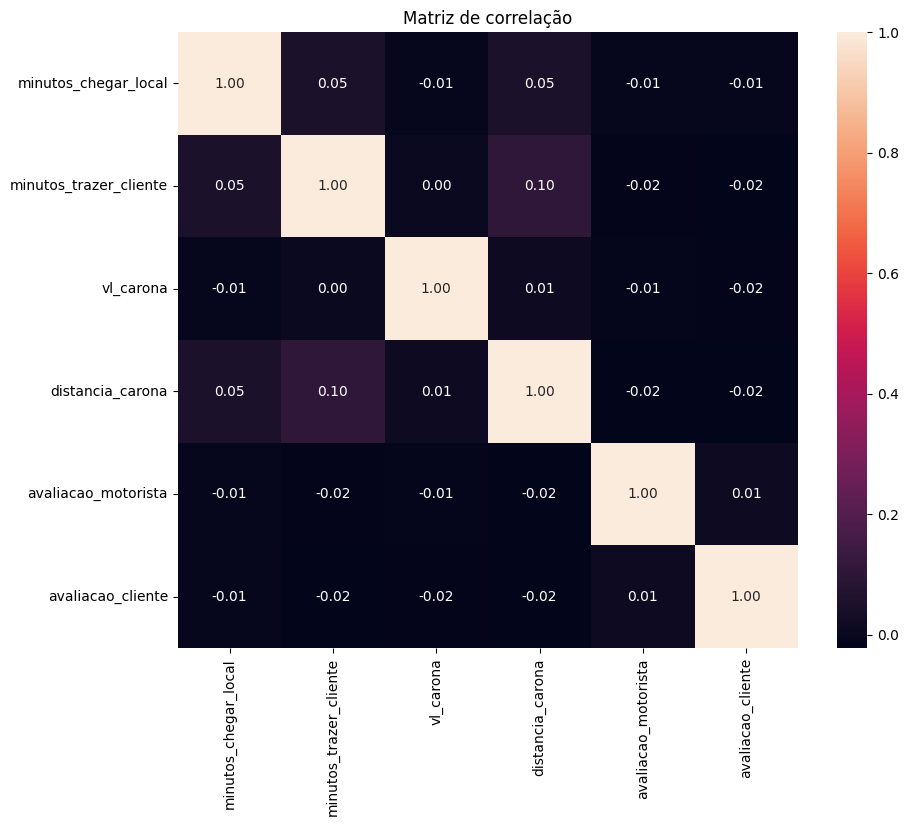

In [39]:
# criando matriz de correlação entre colunas
matriz_correlacao = dataframe[colunas_numericas].corr()

print(matriz_correlacao.round(4))

plt.figure(figsize=(10, 8))
sns.heatmap(matriz_correlacao, 
            annot=True,
            fmt=".2f")
plt.title("Matriz de correlação")
plt.show()

In [40]:
# criando distribuição de horarios e dias com mais demandas
dataframe["dia_semana"] = dataframe["data_hora_carona"].dt.day_name()
dataframe["hora_dia"] = dataframe["data_hora_carona"].dt.hour

qt_caronas_hora = dataframe.groupby("hora_dia")["id_carona"].count().sort_values(ascending=False)
qt_caronas_dia = dataframe.groupby("dia_semana")["id_carona"].count().sort_values(ascending=False)

print(qt_caronas_hora)
print()
print(qt_caronas_dia)

hora_dia
18    12397
19    11047
17    11044
16     9633
20     9630
10     9577
11     8390
9      8234
15     8202
21     8103
14     7031
12     7006
8      6861
13     5470
7      5450
22     5441
6      4160
5      2786
23     2762
3      1383
0      1373
1      1360
2      1339
4      1321
Name: id_carona, dtype: int64

dia_semana
Monday       21644
Saturday     21542
Wednesday    21413
Sunday       21398
Friday       21397
Tuesday      21391
Thursday     21215
Name: id_carona, dtype: int64


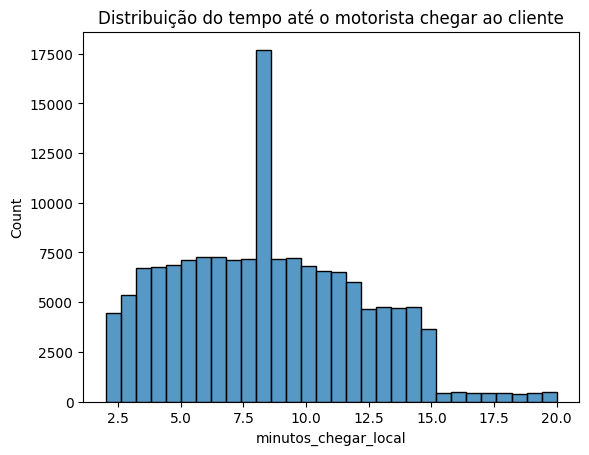

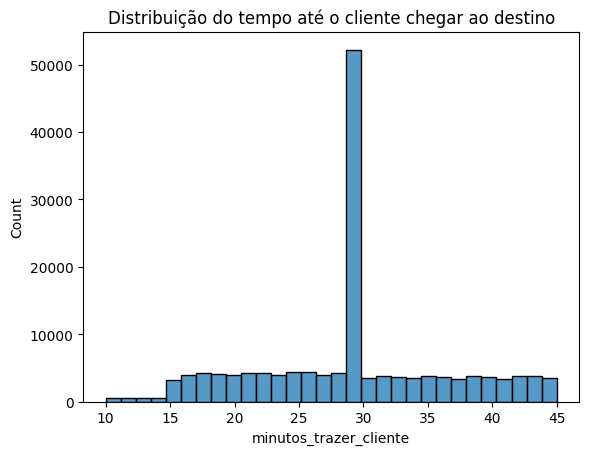

In [41]:
# criando visualizações de dados
# distribuições de tempo de chegada ao local e destino

sns.histplot(dataframe["minutos_chegar_local"], bins=30)
plt.title("Distribuição do tempo até o motorista chegar ao cliente")
plt.show()

sns.histplot(dataframe["minutos_trazer_cliente"], bins=30)
plt.title("Distribuição do tempo até o cliente chegar ao destino")
plt.show()

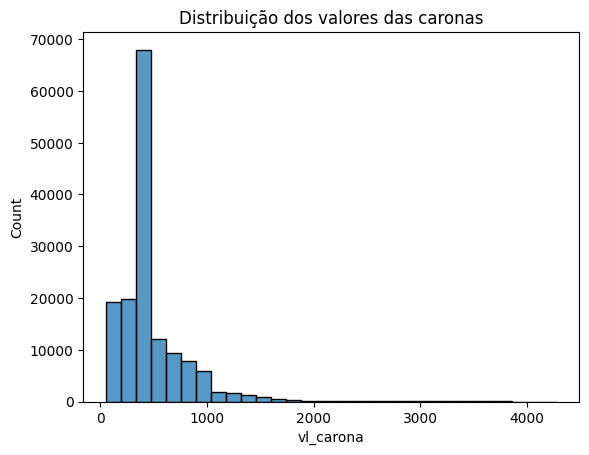

In [42]:
# distribuição de valores das caronas
distribuição_vl_carona = sns.histplot(dataframe["vl_carona"], bins=30)
plt.title("Distribuição dos valores das caronas")
plt.show()

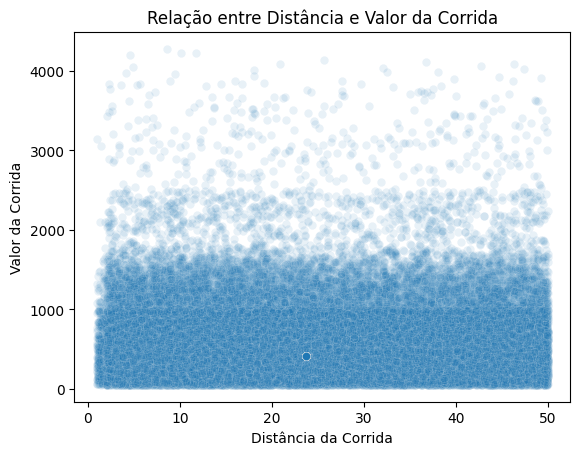

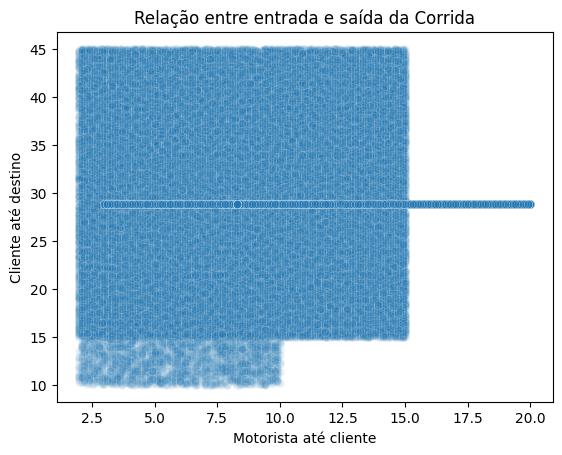

In [43]:
# grafico de dispersão para procurar correlações
sns.scatterplot(data=dataframe, x="distancia_carona", y="vl_carona", alpha=0.1)
plt.title("Relação entre Distância e Valor da Corrida")
plt.xlabel("Distância da Corrida")
plt.ylabel("Valor da Corrida")

plt.show()

sns.scatterplot(data=dataframe, x="minutos_chegar_local", y="minutos_trazer_cliente", alpha=0.1)

plt.title("Relação entre entrada e saída da Corrida")
plt.xlabel("Motorista até cliente")
plt.ylabel("Cliente até destino")

plt.show()

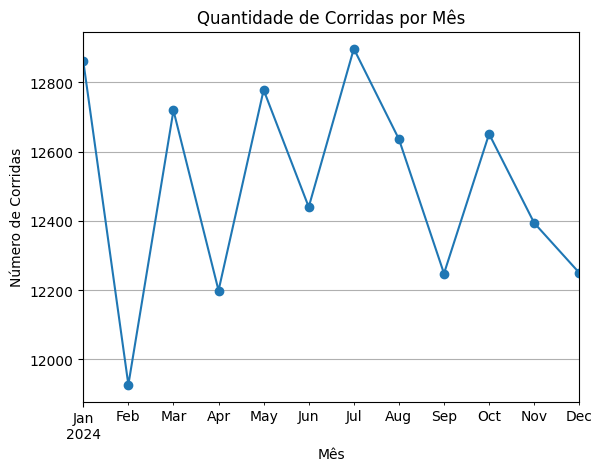

In [44]:
# grafico de linhas para visualizar meses com mais demanda e possiveis tendencias
dataframe["mes"] = dataframe["data_hora_carona"].dt.to_period("M")
caronas_mes = dataframe.groupby("mes").size()

caronas_mes.plot(kind="line", marker="o")

plt.title("Quantidade de Corridas por Mês")
plt.xlabel("Mês")
plt.ylabel("Número de Corridas")
plt.grid(True)

plt.show()